In [ ]:
import pandas as pd 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score

df=pd.read_csv(r"C:\Users\Vaish\Desktop\ML LAB DATASETS LOGISTIC REGRESSION\BATCH-6\27_rain_prediction.csv")


In [12]:
print("------------HEAD---------------")
print(df.head())
print("-----------TAIL-----------------")
print(df.tail())
print("--------------DESCRIBE-----------")
print(df.describe())
print("----------------INFO-------------")
print(df.info())
print("--------------------MISSING VALUES----------------")
print(df.isnull().sum())


------------HEAD---------------
   humidity_pct  pressure_hpa  wind_speed_kmh  cloud_cover_pct  season region  \
0         71.27       1011.44           22.04            30.62  Spring  North   
1         89.30        991.46           35.69            11.98  Winter   West   
2         39.07        987.64           36.45            30.78  Winter  North   
3         27.36        980.75            1.96            33.31    Fall  North   
4         61.52       1017.88           26.38            74.10  Winter  South   

  sky_condition  will_rain  
0      Overcast          1  
1        Cloudy          1  
2         Clear          0  
3         Clear          0  
4      Overcast          1  
-----------TAIL-----------------
     humidity_pct  pressure_hpa  wind_speed_kmh  cloud_cover_pct  season  \
295         29.54       1012.18            3.73            53.26  Summer   
296         97.77       1000.36            1.46            77.59  Summer   
297         40.77        997.26           25.9

In [13]:
X = df.drop("will_rain", axis=1)
y = df["will_rain"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 12)
Testing data: (60, 12)


In [14]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


C:\Users\megha\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
z = model.decision_function(X_test)

probability = 1 / (1 + np.exp(-z))

print("Sigmoid probabilities:")
print(probability[:10])

Sigmoid probabilities:
[0.29587715 0.83282781 0.15731437 0.62516726 0.42152388 0.86266748
 0.76492143 0.24713182 0.89867421 0.67784291]


In [16]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("Predicted labels:")
print(y_pred[:10])

print("\nPredicted probabilities:")
print(y_prob[:10])

Predicted labels:
[0 1 0 1 0 1 1 0 1 1]

Predicted probabilities:
[0.29587715 0.83282781 0.15731437 0.62516726 0.42152388 0.86266748
 0.76492143 0.24713182 0.89867421 0.67784291]


In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[21  5]
 [ 7 27]]
Accuracy: 0.8
Precision: 0.84375
Recall: 0.7941176470588235
F1 Score: 0.8181818181818182


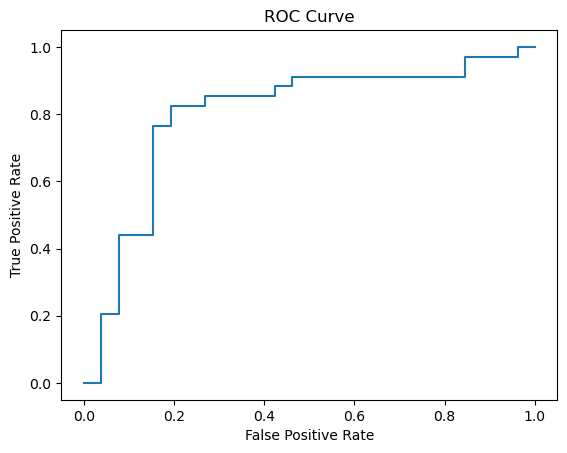

AUC: 0.8009049773755657


In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", auc)

In [19]:
threshold = 0.7

y_pred_new = (y_prob >= threshold).astype(int)

print("Predictions with threshold 0.7:")
print(y_pred_new[:20])

Predictions with threshold 0.7:
[0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 1 0 0]


In [20]:
new_data = pd.DataFrame({
    "humidity_pct": [75],
    "pressure_hpa": [1005],
    "wind_speed_kmh": [20],
    "cloud_cover_pct": [70],
    "season": ["Winter"],
    "region": ["North"],
    "sky_condition": ["Cloudy"]
})

new_data = pd.get_dummies(new_data, drop_first=True)

new_data = new_data.reindex(columns=X.columns, fill_value=0)

new_probability = model.predict_proba(new_data)[:, 1]
new_prediction = (new_probability >= 0.7).astype(int)

print("Rain probability:", new_probability[0])
print("Prediction:", new_prediction[0])

Rain probability: 0.6931660921089685
Prediction: 0
